In [2]:


import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import BayesianGaussianMixture as BGMM
from OPLS_MD import OPLS, OPLS_PLS, PLS
import shap
import matplotlib.pyplot as plt


In [3]:


# Load California Housing Dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target #median house values in California



In [4]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
def scale_features(X):
    # Scale features for PLS regression
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)
    return X_scaled
    
def optimize_n_components(X, y, maxcomp=5, train_split=0.5, plateau_threshold=0.03, plateau_streak=2):
    # Initialize a dictionary to store scores
    data = {
        "proj": {
            "ncomp": [],
            "test_scores": [],
            "train_scores": [],
            "test_scores_opls": [],
            "train_scores_opls": []
        }
    }

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=train_split, random_state=42
    )

    # Iterate over different numbers of components
    for ncomp in range(1, maxcomp + 1):
        print(f"Building models with {ncomp} components", end="\r")
        pls = PLSRegression(n_components=ncomp).fit(X_train, y_train)
        
        # Assuming OPLS_PLS is a valid class similar to PLSRegression
        opls = OPLS_PLS(pls_components=ncomp).fit(X_train, y_train)

        # Save the scores in the data dictionary
        data["proj"]["ncomp"].append(ncomp)
        data["proj"]["test_scores"].append(pls.score(X_test, y_test))
        data["proj"]["train_scores"].append(pls.score(X_train, y_train))
        data["proj"]["test_scores_opls"].append(opls.score(X_test, y_test))
        data["proj"]["train_scores_opls"].append(opls.score(X_train, y_train))
        
        print(f"Train score: {data['proj']['train_scores_opls'][-1]}")
        print(f"Test score: {data['proj']['test_scores_opls'][-1]}")

    print(f"Done! Built models up to {maxcomp} components.")
    
    # Plot scores over numbers of components
    fig, ax = plt.subplots(1)

    ax.plot(data["proj"]["ncomp"], data["proj"]["test_scores"], "--", c="C0", label="PLS Test Scores")
    ax.plot(data["proj"]["ncomp"], data["proj"]["train_scores"], "--", c="C1", label="PLS Train Scores")
    ax.plot(data["proj"]["ncomp"], data["proj"]["test_scores_opls"], c="C0", label="OPLS Test Scores")
    ax.plot(data["proj"]["ncomp"], data["proj"]["train_scores_opls"], c="C1", label="OPLS Train Scores")

    ax.legend()
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Coefficient of Determination (R²)")
    ax.set_title("Model Performance vs Number of Components")
    fig.set_size_inches(10, 6)
    fig.tight_layout()
    plt.show()

    # Determine the optimal number of components for PLS and OPLS
    optimal_n_pls = data["proj"]["ncomp"][np.argmax(data["proj"]["test_scores"])]
    optimal_n_opls = data["proj"]["ncomp"][np.argmax(data["proj"]["test_scores_opls"])]
    

    # Check for plateauing performance
    def find_plateau_index(scores):
        for i in range(1, len(scores)):
            if i >= plateau_streak:
                # Calculate the average change over the last `plateau_streak` components
                avg_change = np.mean(np.abs(np.diff(scores[i - plateau_streak:i])))
                if avg_change < plateau_threshold:
                    return i  # Return the index where plateauing starts
        return len(scores)  # If no plateauing detected, return the length of scores

    plateau_index_pls = find_plateau_index(data["proj"]["test_scores"])
    plateau_index_opls = find_plateau_index(data["proj"]["test_scores_opls"])

    # Determine the optimal number of components based on plateauing
    optimal_n_pls_plateau = data["proj"]["ncomp"][plateau_index_pls - 1] if plateau_index_pls > 0 else optimal_n_pls
    optimal_n_opls_plateau = data["proj"]["ncomp"][plateau_index_opls - 1] if plateau_index_opls > 0 else optimal_n_opls

    return optimal_n_pls, optimal_n_opls, optimal_n_pls_plateau, optimal_n_opls_plateau



def find_optimal_components(X, y, max_components=8, cv_folds=5):
    # Store results
    cv_scores = []
    
    # Iterate over the number of components
    for n in range(1, max_components + 1):
        pls = PLSRegression(n_components=n)
        # Perform cross-validation and calculate mean R²
        scores = cross_val_score(pls, X, y, cv=cv_folds, scoring='r2')
        cv_scores.append(scores.mean())
    
    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_components + 1), cv_scores, marker='o')
    plt.title('Cross-Validated R² vs Number of Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Mean Cross-Validated R²')
    plt.grid()
    plt.xticks(range(1, max_components + 1))
    plt.show()
    
    # Find the optimal number of components
    optimal_n = np.argmax(cv_scores) + 1  # +1 because index starts at 0
    print(f'Optimal number of components: {optimal_n}')



Train score: 0.49099152877602226s
Test score: 0.48907193982400854
Train score: 0.5203720953652928ts
Test score: 0.5213486754067918
Train score: 0.5876337934761209ts
Test score: 0.5924857182193465
Train score: 0.5956697855080034ts
Test score: 0.5980037355630639
Train score: 0.59759323054113ents
Test score: 0.5994628384630483
Train score: 0.6036863266264734ts
Test score: 0.6069984756067637
Train score: 0.6038077208238218ts
Test score: 0.607521817709418
Done! Built models up to 7 components.


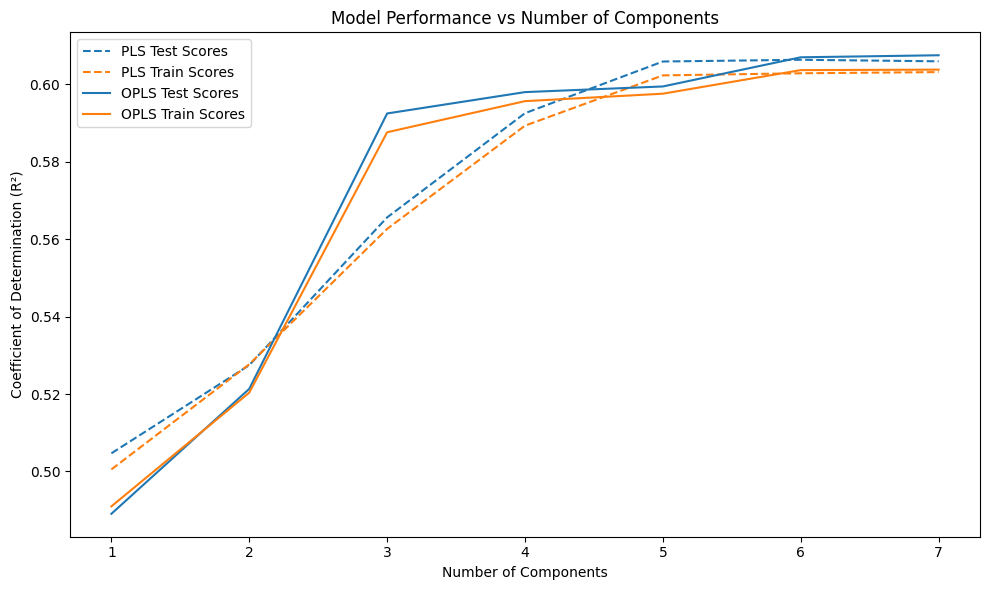

(6, 7, 2, 4)

In [6]:


# Use a subset of 1000 samples for computational efficiency
np.random.seed(42)
subset_indices = np.random.choice(len(X), 20000, replace=False)
X_subset = X.iloc[subset_indices]
y_subset = y[subset_indices]

X_scaled = scale_features(X_subset)

#Example usage:

optimize_n_components(X_scaled, y_subset, maxcomp=7)

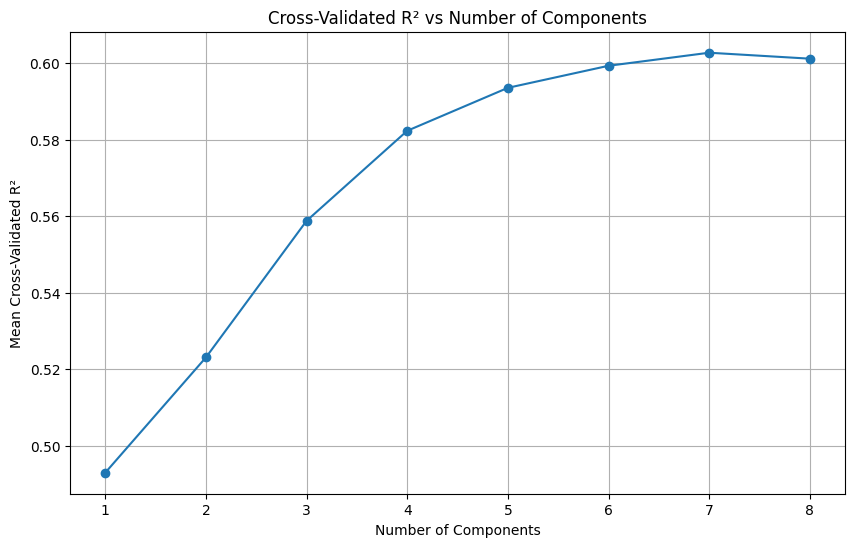

Optimal number of components: 7


In [7]:
# Example usage:
X, y = X_scaled, y_subset
find_optimal_components(X, y)

In [8]:
# Train PLS regression model
pls = PLSRegression(n_components=3)
pls.fit(X_scaled, y_subset)

# Compute predictions
y_pred = pls.predict(X_scaled)


# Compute SHAP values using LinearExplainer
explainer = shap.LinearExplainer(pls, X_scaled)
shap_values = explainer.shap_values(X_scaled)


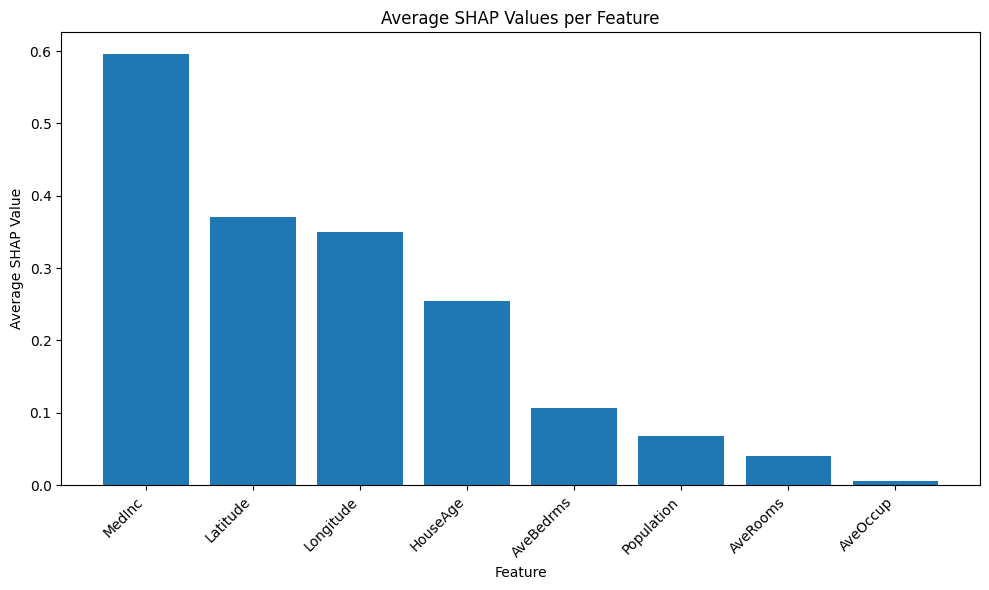

In [9]:
avg_shap_values = np.mean(np.abs(shap_values), axis=0)
avg_shap_df = pd.DataFrame({'Feature': housing.feature_names, 'Average_SHAP_Value': avg_shap_values}).sort_values(by='Average_SHAP_Value', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(range(len(avg_shap_df)), avg_shap_df['Average_SHAP_Value'], tick_label=avg_shap_df['Feature'])
plt.xlabel('Feature')
plt.ylabel('Average SHAP Value')
plt.title('Average SHAP Values per Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('average_shap_bar_plot.png')

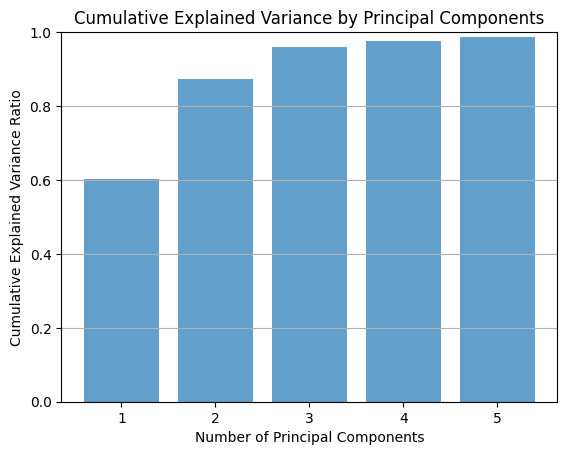

In [33]:


# Apply PCA to reduce SHAP values to 2D
pca = PCA(n_components=5)
shap_pca = pca.fit_transform(shap_values)



#plt.plot(pca.explained_variance_ratio_, marker='o')

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance as a bar plot
plt.bar(range(1, len(cumulative_variance) + 1), cumulative_variance, alpha=0.7)
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")  # X-axis label
plt.ylabel("Cumulative Explained Variance Ratio")  # Y-axis label
plt.ylim(0, 1)  # Set y-axis limits to [0, 1] for better visualization
plt.grid(axis='y')  # Add horizontal grid lines for better readability
plt.xticks(np.arange(1, len(cumulative_variance) + 1))  # Set x-ticks to show component numbers
plt.show()

In [11]:


# Perform k-means clustering
gmm = BGMM(n_components=4, reg_covar = 0.001)
cluster_labels = gmm.fit_predict(shap_pca)



In [12]:


# Step 1: Create a DataFrame for the original SHAP values and cluster labels
shap_df = pd.DataFrame(shap_values, columns=housing.feature_names)  # Replace with your actual feature names if different
shap_df['Cluster'] = cluster_labels  # Add the cluster labels to the DataFrame

# Step 2: Compute mean for each cluster
cluster_means = shap_df.groupby('Cluster').mean()

# Step 3: Display the mean values for each cluster
print("Mean Feature Values per Cluster:")
print(cluster_means)



Mean Feature Values per Cluster:
           MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
Cluster                                                                  
0       -0.143916 -0.028294  0.031561  -0.099608   -0.000027  0.001665   
1        1.403860 -0.217310  0.001324  -0.102079    0.232758 -0.016534   
2       -0.041195 -0.018139  0.038449  -0.102102    0.020770 -0.000031   
3       -0.333537 -0.275205 -0.142949   0.331435   -0.055705  0.002563   

         Latitude  Longitude  
Cluster                       
0       -0.413189   0.380843  
1       -0.002984   0.035447  
2        0.329951  -0.314990  
3       -0.142078  -0.197081  


In [13]:

# Step 2: Get PCA loadings
loadings = pca.components_

# Step 3: Create a DataFrame for the loadings
loadings_df = pd.DataFrame(loadings, columns=housing.feature_names, index=[f'PC{i+1}' for i in range(loadings.shape[0])])

# Step 4: Display the loadings
print("PCA Loadings:")
print(loadings_df)


PCA Loadings:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
PC1  0.996858 -0.051793 -0.023083  -0.009401    0.002151 -0.001738  0.053999   
PC2 -0.045801 -0.041620  0.009751  -0.006442    0.024879  0.000255  0.721052   
PC3  0.045811  0.982538  0.027101  -0.046347   -0.121226 -0.003000  0.111291   
PC4  0.011985  0.052449 -0.363855   0.840016   -0.253627  0.010815 -0.199225   
PC5 -0.003693  0.101020 -0.105345   0.312006    0.901688 -0.084599  0.159451   

     Longitude  
PC1  -0.006782  
PC2  -0.689564  
PC3   0.050467  
PC4  -0.234424  
PC5   0.188977  


In [14]:
# Optional: Identify top features for each component
for i in range(loadings_df.shape[0]):
    print(f"\nTop features for {loadings_df.index[i]}:")
    top_features = loadings_df.iloc[i].abs().nlargest(3)  # Change 3 to however many top features you want
    print(top_features)


Top features for PC1:
MedInc      0.996858
Latitude    0.053999
HouseAge    0.051793
Name: PC1, dtype: float64

Top features for PC2:
Latitude     0.721052
Longitude    0.689564
MedInc       0.045801
Name: PC2, dtype: float64

Top features for PC3:
HouseAge      0.982538
Population    0.121226
Latitude      0.111291
Name: PC3, dtype: float64

Top features for PC4:
AveBedrms     0.840016
AveRooms      0.363855
Population    0.253627
Name: PC4, dtype: float64

Top features for PC5:
Population    0.901688
AveBedrms     0.312006
Longitude     0.188977
Name: PC5, dtype: float64


In [15]:

# Optional: Identify top features for each cluster
for cluster in cluster_means.index:
    print(f"\nTop features for Cluster {cluster}:")
    top_features = cluster_means.loc[cluster].abs().nlargest(3)  # Change 3 to however many top features you want
    print(top_features)


Top features for Cluster 0:
Latitude     0.413189
Longitude    0.380843
MedInc       0.143916
Name: 0, dtype: float64

Top features for Cluster 1:
MedInc        1.403860
Population    0.232758
HouseAge      0.217310
Name: 1, dtype: float64

Top features for Cluster 2:
Latitude     0.329951
Longitude    0.314990
AveBedrms    0.102102
Name: 2, dtype: float64

Top features for Cluster 3:
MedInc       0.333537
AveBedrms    0.331435
HouseAge     0.275205
Name: 3, dtype: float64


Text(0.5, 1.0, 'K-Means Clustering of SHAP Values (PCA-Reduced)')

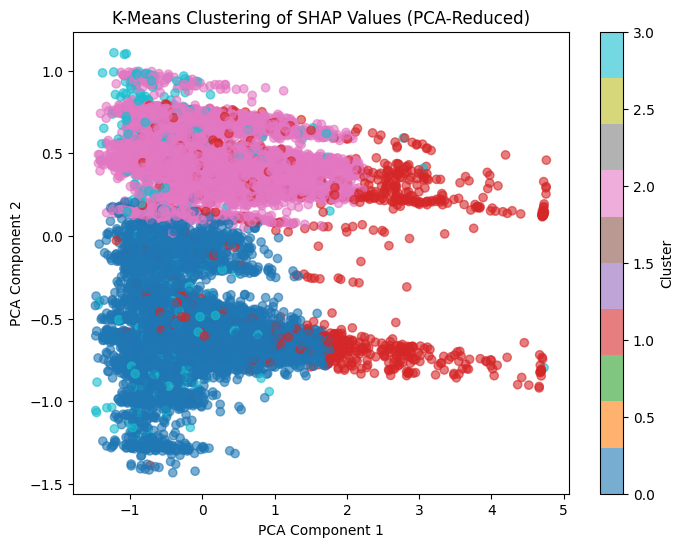

In [16]:


# Visualize clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(shap_pca[:, 0], shap_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of SHAP Values (PCA-Reduced)')
#plt.savefig('shapley_clusters.png')
#plt.close()



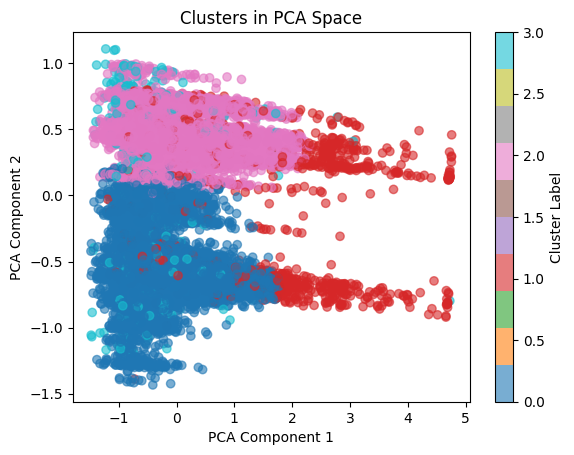

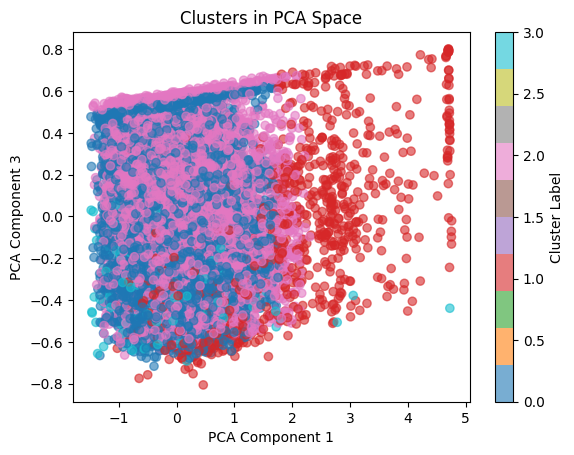

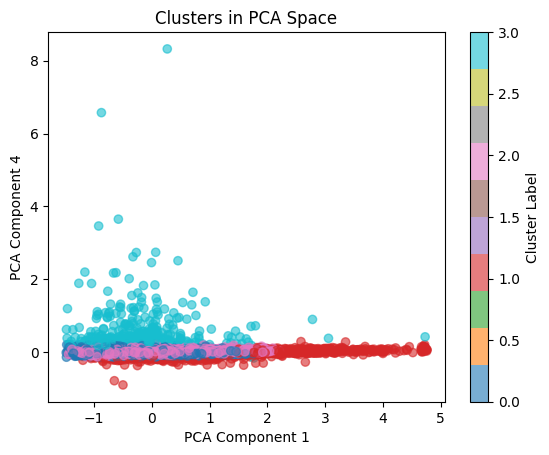

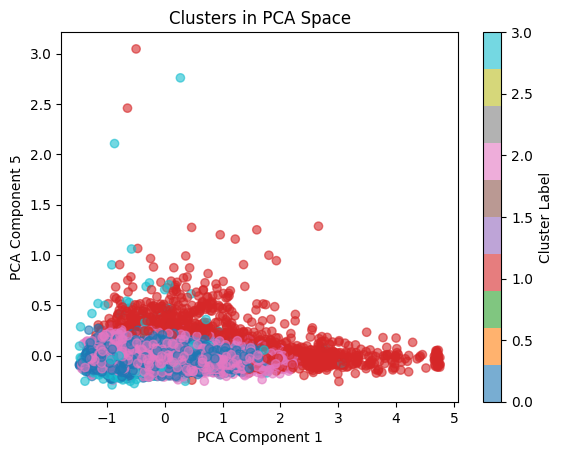

In [17]:
for i in range(1, 5):
    plt.figure()
    plt.scatter(shap_pca[:, 0], shap_pca[:, i], alpha=0.6, c=cluster_labels, cmap='tab10')
    plt.xlabel('PCA Component 1')
    plt.ylabel(f'PCA Component {i + 1}')
    plt.title('Clusters in PCA Space')
    plt.colorbar(label='Cluster Label')  # Add a color bar to indicate cluster labels
    #plt.savefig(f'cluster_{i}_visualization.png')


In [18]:


# Analyze clusters: Compute mean SHAP values per cluster
shap_df = pd.DataFrame(shap_values, columns=housing.feature_names)
shap_df['Cluster'] = cluster_labels
cluster_means = shap_df.groupby('Cluster').mean()

# Save results to CSV for interpretation
cluster_means.to_csv('cluster_shap_means.csv')

# Print summary
print("Cluster Mean SHAP Values:")
print(cluster_means)



Cluster Mean SHAP Values:
           MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
Cluster                                                                  
0       -0.143916 -0.028294  0.031561  -0.099608   -0.000027  0.001665   
1        1.403860 -0.217310  0.001324  -0.102079    0.232758 -0.016534   
2       -0.041195 -0.018139  0.038449  -0.102102    0.020770 -0.000031   
3       -0.333537 -0.275205 -0.142949   0.331435   -0.055705  0.002563   

         Latitude  Longitude  
Cluster                       
0       -0.413189   0.380843  
1       -0.002984   0.035447  
2        0.329951  -0.314990  
3       -0.142078  -0.197081  


/tmp/ipykernel_408/1283660401.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled, feature_names=housing.feature_names)


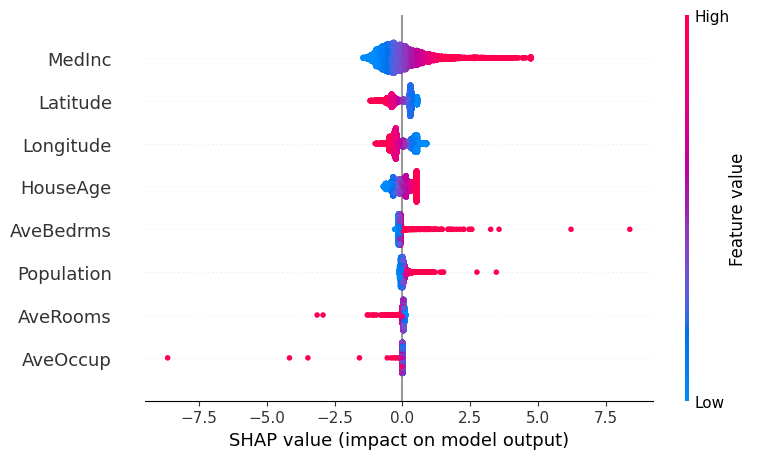

In [19]:
# Summary plot
shap.summary_plot(shap_values, X_scaled, feature_names=housing.feature_names)


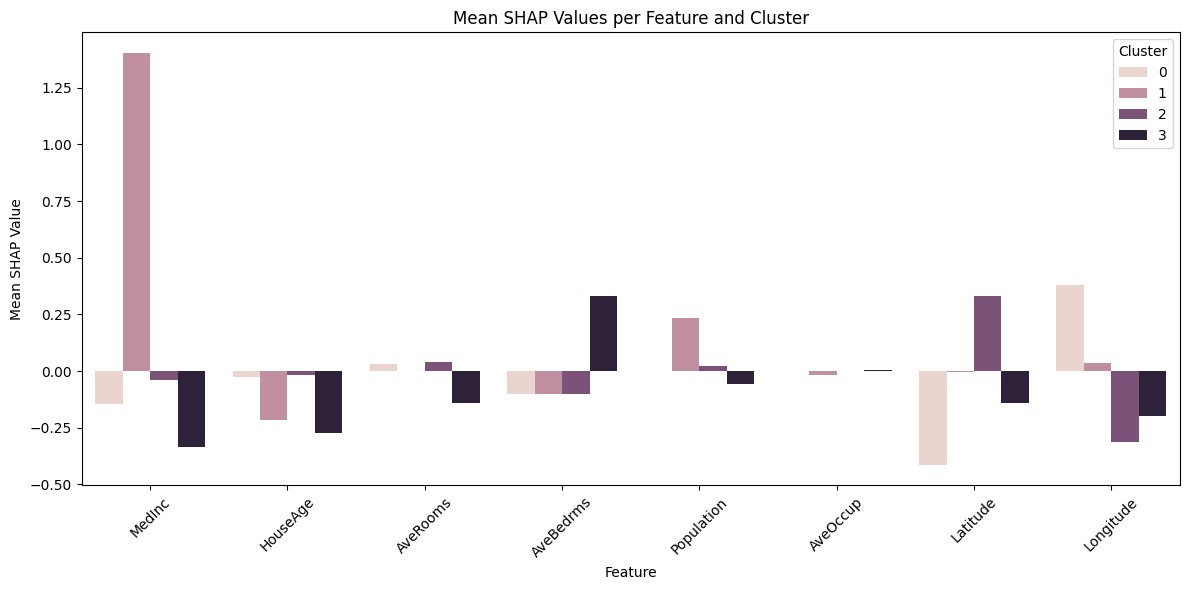

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert cluster_means to a DataFrame for easier plotting
cluster_means_df = cluster_means.reset_index()

# Melt the DataFrame for easier plotting with seaborn
melted_means = cluster_means_df.melt(id_vars='Cluster', var_name='Feature', value_name='Mean SHAP Value')

# Set the plot size
plt.figure(figsize=(12, 6))

# Create a bar plot
sns.barplot(data=melted_means, x='Feature', y='Mean SHAP Value', hue='Cluster')

# Customize the plot
plt.title('Mean SHAP Values per Feature and Cluster')
plt.xticks(rotation=45)
plt.ylabel('Mean SHAP Value')
plt.xlabel('Feature')
plt.legend(title='Cluster')
plt.tight_layout()

# Show the plot
plt.show()
